In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ttest_ind
import matplotlib.gridspec as gridspec
import mne
from matplotlib import ticker

In [2]:
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

def add_subplot_label(ax, label, x=-.21, y=1.2225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

In [3]:
behav_df = pd.read_csv('./data/derivatives/behav_df_cleaned_new.csv')
behav_df = behav_df[behav_df['reach_vis_abs_err']<=60].reset_index(drop=True)

burst_df = pd.read_csv('./data/derivatives/burst_features.csv')

lookup_df = behav_df[["coh_cat", "perturb_cat", "trial", "block", "subject", "group"]]
df_burst_behav = burst_df.merge(
    lookup_df, 
    on=["trial", "block", "subject"], 
    how='left'
)

In [4]:
burst_df_vis = df_burst_behav[df_burst_behav['epoch'] == 'vis']
burst_df_mot = df_burst_behav[df_burst_behav['epoch'] == 'mot']

# Save to CSV
burst_df_vis.to_csv('./output/burst_features_vis.csv', index=False)
burst_df_mot.to_csv('./output/burst_features_mot.csv', index=False)

In [5]:
waveform_array_file = './data/derivatives/all_waveforms.npy'
waveform_array = np.load(waveform_array_file)
waveform_time = np.linspace(-.13, .13, num=156)

In [6]:
implicit_subjects = behav_df[behav_df['group'] == 'Implicit']['subject'].unique()
explicit_subjects = behav_df[behav_df['group'] == 'Explicit']['subject'].unique()

In [7]:
mask_visual_implicit = (
    (df_burst_behav["epoch"] == "vis") &
    (df_burst_behav["subject"].isin(implicit_subjects))
)
waveform_array_implicit_visual = waveform_array[mask_visual_implicit, :]

mask_visual_explicit = (
    (df_burst_behav["epoch"] == "vis") &
    (df_burst_behav["subject"].isin(explicit_subjects))
)
waveform_array_explicit_visual = waveform_array[mask_visual_explicit, :]


mask_motor_implicit = (
    (df_burst_behav["epoch"] == "mot") &
    (df_burst_behav["subject"].isin(implicit_subjects))
)
waveform_array_implicit_motor = waveform_array[mask_motor_implicit, :]

mask_motor_explicit = (
    (df_burst_behav["epoch"] == "mot") &
    (df_burst_behav["subject"].isin(explicit_subjects))
)
waveform_array_explicit_motor = waveform_array[mask_motor_explicit, :]

In [8]:
# def signaltonoise(a, axis=0, ddof=0):
#     a = np.asanyarray(a)
#     m = a.mean(axis)
#     sd = a.std(axis=axis, ddof=ddof)
#     return np.where(sd == 0, 0, m/sd)

# SNR = signaltonoise(waveform_array, axis=0, ddof=1)

In [9]:
from multiprocessing import Pool, cpu_count

def _process_chunk(args):
    """Worker function to process a single chunk"""
    chunk, axis = args
    sum_a = chunk.sum(axis=axis)
    sum_sq = (chunk**2).sum(axis=axis)
    return sum_a, sum_sq

def signaltonoise_parallel(a, axis=0, ddof=0, chunk_size=1000000, n_jobs=None):
    """Process large arrays in parallel chunks"""
    if n_jobs is None:
        n_jobs = cpu_count()
    
    n_samples = a.shape[axis]
    n_channels = a.shape[1] if axis == 0 else a.shape[0]
    
    # Prepare chunks
    chunks = []
    for i in range(0, n_samples, chunk_size):
        chunk = a[i:i+chunk_size] if axis == 0 else a[:, i:i+chunk_size]
        chunks.append((chunk, axis))
    
    # Process chunks in parallel
    with Pool(n_jobs) as pool:
        results = pool.map(_process_chunk, chunks)
    
    # Accumulate results
    sum_a = np.zeros(n_channels, dtype=np.float64)
    sum_sq = np.zeros(n_channels, dtype=np.float64)
    
    for chunk_sum, chunk_sum_sq in results:
        sum_a += chunk_sum
        sum_sq += chunk_sum_sq
    
    # Compute SNR
    m = sum_a / n_samples
    var = (sum_sq / n_samples - m**2) * (n_samples / (n_samples - ddof))
    sd = np.sqrt(np.maximum(var, 0))
    
    return np.where(sd == 0, 0, m / sd)

# Use it
SNR = signaltonoise_parallel(waveform_array, axis=0, ddof=1)

In [10]:
mean_waveform_implicit_visual = waveform_array_implicit_visual.mean(axis=0)
mean_waveform_explicit_visual = waveform_array_explicit_visual.mean(axis=0)
mean_waveform_implicit_motor = waveform_array_implicit_motor.mean(axis=0)
mean_waveform_explicit_motor = waveform_array_explicit_motor.mean(axis=0)

SNR_implicit_visual = signaltonoise_parallel(waveform_array_implicit_visual, axis=0, ddof=1)
SNR_explicit_visual = signaltonoise_parallel(waveform_array_explicit_visual, axis=0, ddof=1)
SNR_implicit_motor = signaltonoise_parallel(waveform_array_implicit_motor, axis=0, ddof=1)
SNR_explicit_motor = signaltonoise_parallel(waveform_array_explicit_motor, axis=0, ddof=1)

In [11]:
# Convert time to ms
waveform_time_ms = waveform_time * 1000


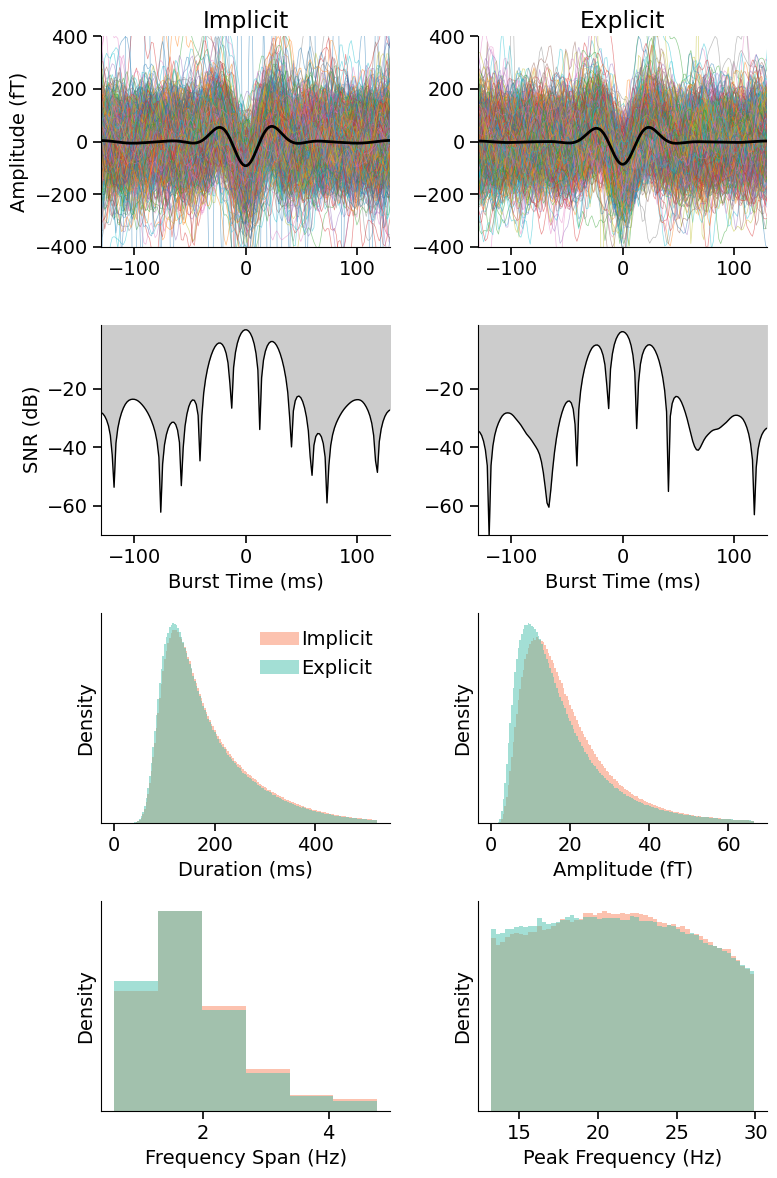

In [12]:
palette0 = sns.color_palette("magma_r", 3)
palette1 = sns.color_palette("mako_r", 3)
    
fig = plt.figure(figsize=(8, 12))
gs = fig.add_gridspec(4, 2)

ax1 = fig.add_subplot(gs[0, 0])   # Implicit waveforms
ax2 = fig.add_subplot(gs[0, 1])   # Explicit waveforms
ax3 = fig.add_subplot(gs[1, 0])   # Implicit SNR
ax4 = fig.add_subplot(gs[1, 1])   # Explicit SNR
ax5 = fig.add_subplot(gs[2, 0])   # Duration
ax6 = fig.add_subplot(gs[2, 1])   # Amplitude
ax7 = fig.add_subplot(gs[3, 0])   # Freq span
ax8 = fig.add_subplot(gs[3, 1])   # Peak freq

# Implicit Waveforms
ax1.plot(
    waveform_time_ms,
    waveform_array_implicit_visual[::5000].T / 1e-15,  # downsample if needed
    lw=0.5, alpha=0.5,
    rasterized=True
)
ax1.plot(
    waveform_time_ms,
    mean_waveform_implicit_visual / 1e-15,
    lw=2, color="black"
)
ax1.set_ylim(-400, 400)
ax1.set_xlim(-130, 130)
ax1.set_ylabel("Amplitude (fT)")
ax1.set_title("Implicit")

# Implicit SNR
ax3.fill_between(
    waveform_time_ms,
    np.zeros_like(waveform_time_ms)+2,
    10 * np.log10(SNR_implicit_visual**2),
    lw=0, color="black", alpha=0.2
)
ax3.plot(
    waveform_time_ms,
    10 * np.log10(SNR_implicit_visual**2),
    lw=1, color="black"
)
ax3.set_ylim(-70, 2)
ax3.set_xlim(-130, 130)
ax3.set_ylabel("SNR (dB)")
ax3.set_yticks([-20, -40, -60])
ax3.set_xlabel("Burst Time (ms)")

# Explicit Waveforms
ax2.plot(
    waveform_time_ms,
    waveform_array_explicit_visual[::5000].T / 1e-15,
    lw=0.5, alpha=0.5,
    rasterized=True
)
ax2.plot(
    waveform_time_ms,
    mean_waveform_explicit_visual / 1e-15,
    lw=2, color="black"
)
ax2.set_ylim(-400, 400)
ax2.set_xlim(-130, 130)
ax2.set_title("Explicit")

# Explicit SNR
ax4.fill_between(
    waveform_time_ms,
    np.zeros_like(waveform_time_ms)+2,
    10 * np.log10(SNR_explicit_visual**2),
    lw=0, color="black", alpha=0.2
)
ax4.plot(
    waveform_time_ms,
    10 * np.log10(SNR_explicit_visual**2),
    lw=1, color="black"
)
ax4.set_ylim(-70, 2)
ax4.set_xlim(-130, 130)
ax4.set_yticks([-20, -40, -60])
ax4.set_xlabel("Burst Time (ms)")

# Duration
fwhm_implicit=df_burst_behav['fwhm_time'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='vis')]*1000
fwhm_explicit=df_burst_behav['fwhm_time'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='vis')]*1000
combined_values = np.concatenate([fwhm_implicit, fwhm_explicit])
max_val = np.percentile(combined_values, 99)
bins = np.linspace(0, max_val, 159)
ax5.hist(
    fwhm_implicit,
    bins=bins,
    color=palette0[0],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Implicit"
)
ax5.hist(
    fwhm_explicit,
    bins=bins,
    color=palette1[0],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Explicit"
)
ax5.set_xlabel("Duration (ms)")
ax5.set_ylabel("Density")
ax5.set_yticks([])
ax5.legend()

# Amplitude
peak_amp_base_implicit=df_burst_behav['peak_amp_base'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='vis')] * 1e15
peak_amp_base_explicit=df_burst_behav['peak_amp_base'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='vis')] * 1e15
combined_values = np.concatenate([peak_amp_base_implicit, peak_amp_base_explicit])
min_val = np.min(combined_values)
max_val = np.percentile(combined_values, 99)
bins = np.linspace(min_val, max_val, 159)
ax6.hist(
    peak_amp_base_implicit, bins=bins, alpha=0.5, density=True, label="Implicit", color=palette0[0],
)
ax6.hist(
    peak_amp_base_explicit, bins=bins, alpha=0.5, density=True, label="Explicit", color=palette1[0],
)
ax6.set_xlabel("Amplitude (fT)")
ax6.set_ylabel("Density")
ax6.set_yticks([])

# Frequency span
fwhm_freq_implicit=df_burst_behav['fwhm_freq'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='vis')]
fwhm_freq_explicit=df_burst_behav['fwhm_freq'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='vis')]
combined_values = np.concatenate([fwhm_freq_implicit, fwhm_freq_explicit])
min_val = np.min(combined_values)
max_val = np.percentile(combined_values, 99)
bins = np.linspace(min_val, max_val, 7)
ax7.hist(
    fwhm_freq_implicit,
    bins=bins,
    color=palette0[0],
    alpha=0.5,             
    linewidth=0.2,
    density=True,          
    label="Implicit"
)
ax7.hist(
    fwhm_freq_explicit,
    bins=bins,
    color=palette1[0],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Explicit"
)
ax7.set_xlabel("Frequency Span (Hz)")
ax7.set_ylabel("Density")
ax7.set_yticks([])

# Peak frequency
peak_freq_implicit=df_burst_behav['peak_freq'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='vis')]
peak_freq_explicit=df_burst_behav['peak_freq'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='vis')]
combined_values = np.concatenate([peak_freq_implicit, peak_freq_explicit])
min_val = np.min(combined_values)
max_val = np.max(combined_values)
bins = np.linspace(min_val, max_val, 58)
ax8.hist(
    peak_freq_implicit,
    bins=bins,
    color=palette0[0],
    alpha=0.5,              # transparency
    linewidth=0.2,
    density=True,          
    label="Implicit"
)
ax8.hist(
    peak_freq_explicit,
    bins=bins,
    color=palette1[0],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Explicit"
)
ax8.set_xlabel("Peak Frequency (Hz)")
ax8.set_ylabel("Density")
ax8.set_yticks([])

plt.tight_layout()
plt.show()

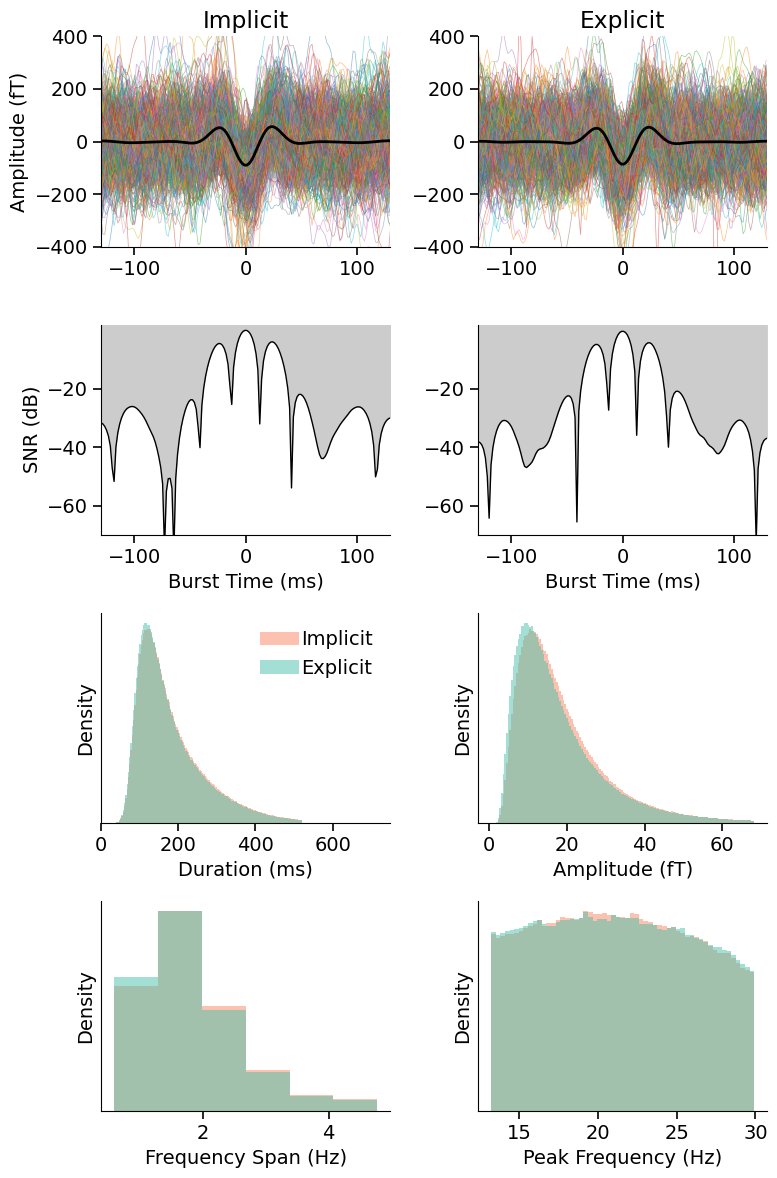

In [13]:
palette0 = sns.color_palette("magma_r", 3)
palette1 = sns.color_palette("mako_r", 3)
    
fig = plt.figure(figsize=(8, 12))
gs = fig.add_gridspec(4, 2)

ax1 = fig.add_subplot(gs[0, 0])   # Implicit waveforms
ax2 = fig.add_subplot(gs[0, 1])   # Explicit waveforms
ax3 = fig.add_subplot(gs[1, 0])   # Implicit SNR
ax4 = fig.add_subplot(gs[1, 1])   # Explicit SNR
ax5 = fig.add_subplot(gs[2, 0])   # Duration
ax6 = fig.add_subplot(gs[2, 1])   # Amplitude
ax7 = fig.add_subplot(gs[3, 0])   # Freq span
ax8 = fig.add_subplot(gs[3, 1])   # Peak freq

# Implicit Waveforms
ax1.plot(
    waveform_time_ms,
    waveform_array_implicit_motor[::5000].T / 1e-15,  # downsample if needed
    lw=0.5, alpha=0.5,
    rasterized=True
)
ax1.plot(
    waveform_time_ms,
    mean_waveform_implicit_motor / 1e-15,
    lw=2, color="black"
)
ax1.set_ylim(-400, 400)
ax1.set_xlim(-130, 130)
ax1.set_ylabel("Amplitude (fT)")
ax1.set_title("Implicit")

# Implicit SNR
ax3.fill_between(
    waveform_time_ms,
    np.zeros_like(waveform_time_ms)+2,
    10 * np.log10(SNR_implicit_motor**2),
    lw=0, color="black", alpha=0.2
)
ax3.plot(
    waveform_time_ms,
    10 * np.log10(SNR_implicit_motor**2),
    lw=1, color="black"
)
ax3.set_ylim(-70, 2)
ax3.set_xlim(-130, 130)
ax3.set_ylabel("SNR (dB)")
ax3.set_yticks([-20, -40, -60])
ax3.set_xlabel("Burst Time (ms)")

# Explicit Waveforms
ax2.plot(
    waveform_time_ms,
    waveform_array_explicit_motor[::5000].T / 1e-15,
    lw=0.5, alpha=0.5,
    rasterized=True
)
ax2.plot(
    waveform_time_ms,
    mean_waveform_explicit_motor / 1e-15,
    lw=2, color="black"
)
ax2.set_ylim(-400, 400)
ax2.set_xlim(-130, 130)
ax2.set_title("Explicit")

# Explicit SNR
ax4.fill_between(
    waveform_time_ms,
    np.zeros_like(waveform_time_ms)+2,
    10 * np.log10(SNR_explicit_motor**2),
    lw=0, color="black", alpha=0.2
)
ax4.plot(
    waveform_time_ms,
    10 * np.log10(SNR_explicit_motor**2),
    lw=1, color="black"
)
ax4.set_ylim(-70, 2)
ax4.set_xlim(-130, 130)
ax4.set_yticks([-20, -40, -60])
ax4.set_xlabel("Burst Time (ms)")

# Duration
fwhm_implicit=df_burst_behav['fwhm_time'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='mot')]*1000
fwhm_explicit=df_burst_behav['fwhm_time'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='mot')]*1000
combined_values = np.concatenate([fwhm_implicit, fwhm_explicit])
max_val = np.percentile(combined_values, 99)
bins = np.linspace(0, max_val, 158)
ax5.hist(
    fwhm_implicit,
    bins=bins,
    color=palette0[0],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Implicit"
)
ax5.hist(
    fwhm_explicit,
    bins=bins,
    color=palette1[0],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Explicit"
)
ax5.set_xlabel("Duration (ms)")
ax5.set_ylabel("Density")
ax5.set_xlim(0, 750)
ax5.set_yticks([])
ax5.legend()

# Amplitude
peak_amp_base_implicit=df_burst_behav['peak_amp_base'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='mot')] * 1e15
peak_amp_base_explicit=df_burst_behav['peak_amp_base'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='mot')] * 1e15
combined_values = np.concatenate([peak_amp_base_implicit, peak_amp_base_explicit])
min_val = np.min(combined_values)
max_val = np.percentile(combined_values, 99)
bins = np.linspace(min_val, max_val, 159)
ax6.hist(
    peak_amp_base_implicit, bins=bins, alpha=0.5, density=True, label="Implicit", color=palette0[0],
)
ax6.hist(
    peak_amp_base_explicit, bins=bins, alpha=0.5, density=True, label="Explicit", color=palette1[0],
)
ax6.set_xlabel("Amplitude (fT)")
ax6.set_ylabel("Density")
ax6.set_yticks([])

# Frequency span
fwhm_freq_implicit=df_burst_behav['fwhm_freq'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='mot')]
fwhm_freq_explicit=df_burst_behav['fwhm_freq'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='mot')]
combined_values = np.concatenate([fwhm_freq_implicit, fwhm_freq_explicit])
min_val = np.min(combined_values)
max_val = np.percentile(combined_values, 99)
bins = np.linspace(min_val, max_val, 7)
ax7.hist(
    fwhm_freq_implicit,
    bins=bins,
    color=palette0[0],
    alpha=0.5,             
    linewidth=0.2,
    density=True,          
    label="Implicit"
)
ax7.hist(
    fwhm_freq_explicit,
    bins=bins,
    color=palette1[0],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Explicit"
)
ax7.set_xlabel("Frequency Span (Hz)")
ax7.set_ylabel("Density")
ax7.set_yticks([])

# Peak frequency
peak_freq_implicit=df_burst_behav['peak_freq'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='mot')]
peak_freq_explicit=df_burst_behav['peak_freq'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='mot')]
combined_values = np.concatenate([peak_freq_implicit, peak_freq_explicit])
min_val = np.min(combined_values)
max_val = np.max(combined_values)
bins = np.linspace(min_val, max_val, 58)
ax8.hist(
    peak_freq_implicit,
    bins=bins,
    color=palette0[0],
    alpha=0.5,              # transparency
    linewidth=0.2,
    density=True,          
    label="Implicit"
)
ax8.hist(
    peak_freq_explicit,
    bins=bins,
    color=palette1[0],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Explicit"
)
ax8.set_xlabel("Peak Frequency (Hz)")
ax8.set_ylabel("Density")
ax8.set_yticks([])

plt.tight_layout()
plt.show()

In [14]:

def add_subplot_label(ax, label, x=-.21, y=1.2225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')
    
colors0 = sns.color_palette("magma", n_colors=6)
colors1 = sns.color_palette("mako_r", n_colors=10)
pastel = sns.color_palette("Pastel1", n_colors=6)
adapt1 = sns.color_palette("Set1", n_colors=9)
adapt2 = sns.color_palette("Accent", n_colors=8)
colors4 = sns.color_palette("magma_r", n_colors=4)
colors5 = sns.color_palette("mako_r", n_colors=4)

colors2 = [pastel[0], pastel[3], adapt2[5]]
colors3 = [pastel[1], pastel[2], colors5[2]]
colors_implicit = [pastel[0], adapt2[5], pastel[3]]  # Baseline, Washout, Adaptation
colors_explicit = [pastel[1], colors5[2], pastel[2]]  # Baseline, Washout, Adaptation
colorbl = [adapt1[4], colors1[2]]

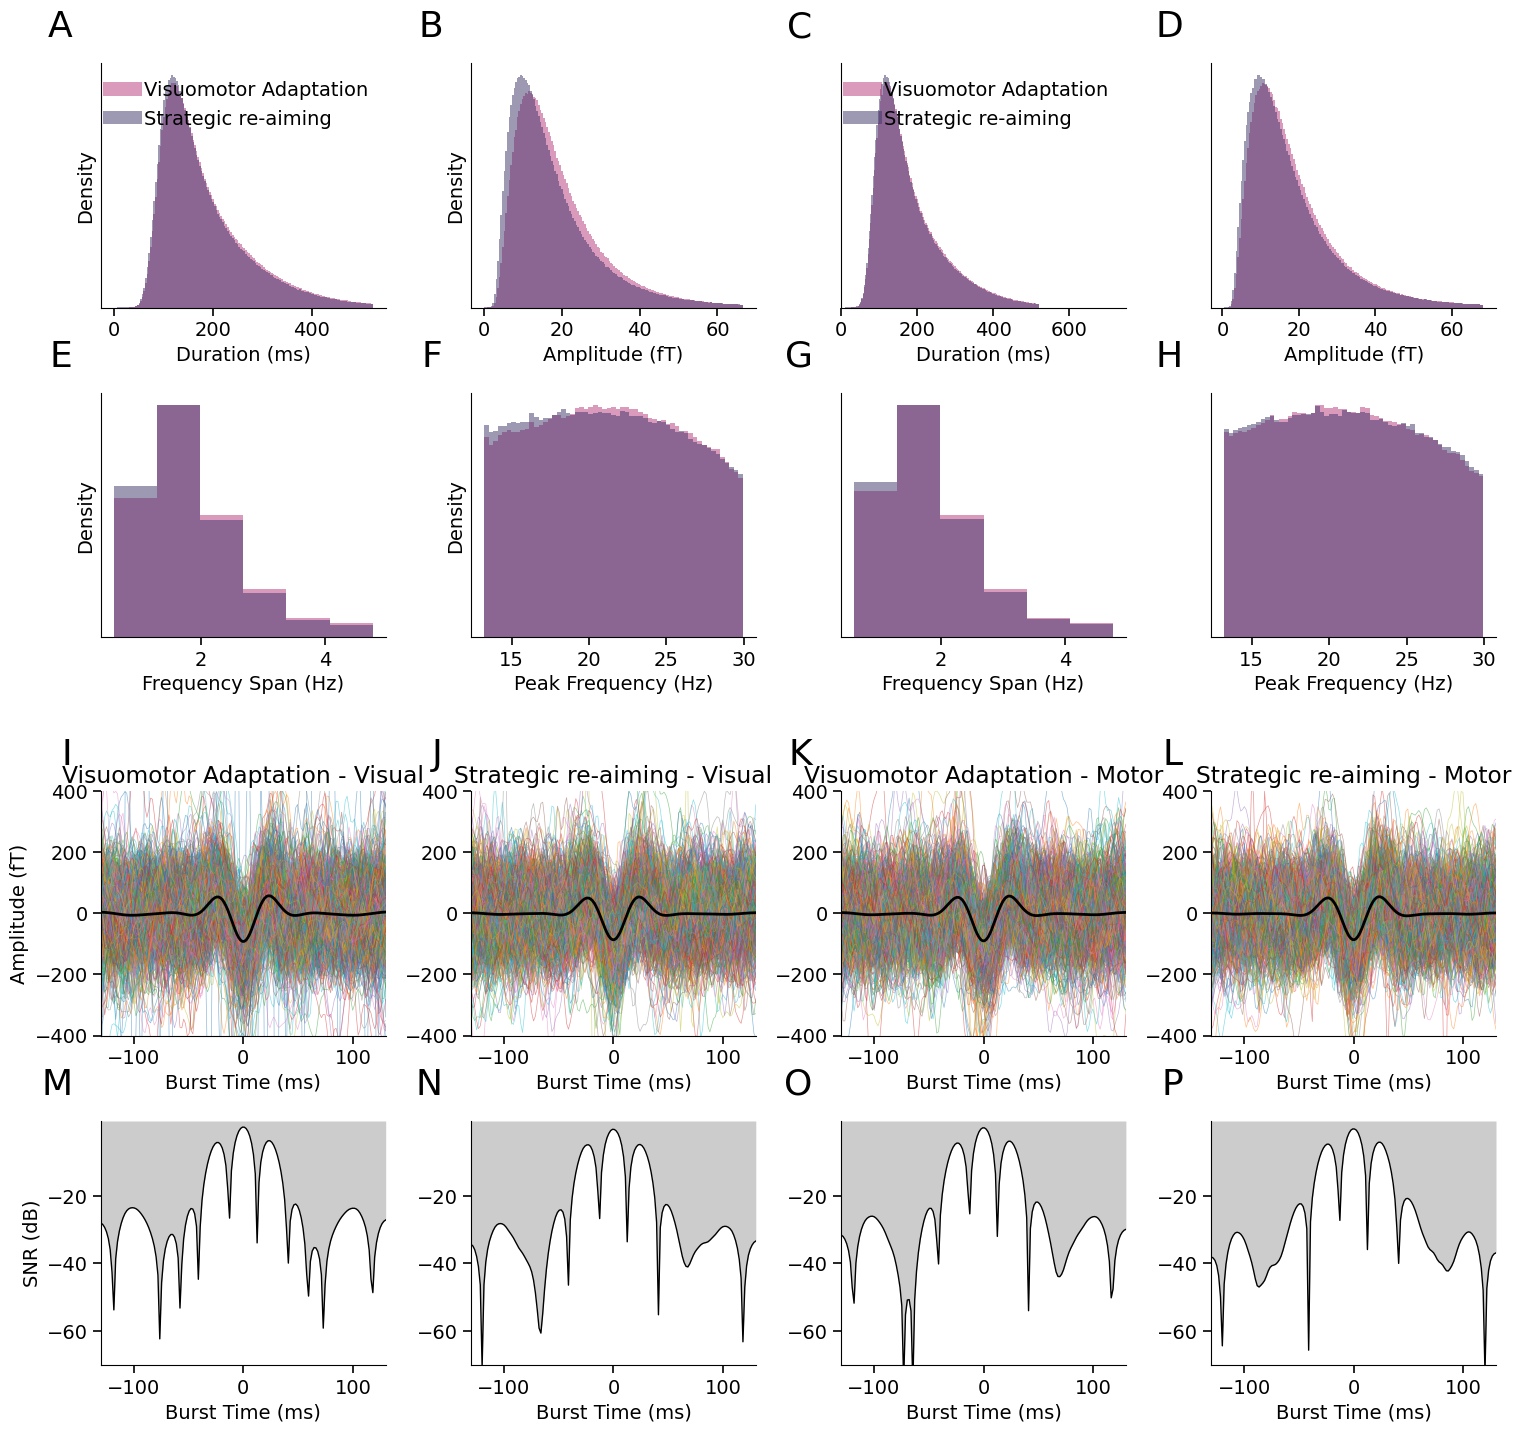

In [15]:
palette0 = sns.color_palette("magma_r", 3)
palette1 = sns.color_palette("mako_r", 3)

fig = plt.figure(figsize=(18, 14))

# Create two separate gridspecs with a gap between them
gs_top = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.3, top=0.95, bottom=0.54)
gs_bottom = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.3, top=0.43, bottom=0.02)

# VISUAL EPOCHS (Left side - columns 0-1)
# Top section
ax5 = fig.add_subplot(gs_top[0, 0])   # Duration - Visual
ax6 = fig.add_subplot(gs_top[0, 1])   # Amplitude - Visual
ax7 = fig.add_subplot(gs_top[1, 0])   # Freq span - Visual
ax8 = fig.add_subplot(gs_top[1, 1])   # Peak freq - Visual

# Bottom section
ax1 = fig.add_subplot(gs_bottom[0, 0])   # Visuomotor Adaptation waveforms - Visual
ax2 = fig.add_subplot(gs_bottom[0, 1])   # Strategic re-aiming waveforms - Visual
ax3 = fig.add_subplot(gs_bottom[1, 0])   # Visuomotor Adaptation SNR - Visual
ax4 = fig.add_subplot(gs_bottom[1, 1])   # Strategic re-aiming SNR - Visual

# MOTOR EPOCHS (Right side - columns 2-3)
# Top section
ax13 = fig.add_subplot(gs_top[0, 2])  # Duration - Motor
ax14 = fig.add_subplot(gs_top[0, 3])  # Amplitude - Motor
ax15 = fig.add_subplot(gs_top[1, 2])  # Freq span - Motor
ax16 = fig.add_subplot(gs_top[1, 3])  # Peak freq - Motor

# Bottom section
ax9 = fig.add_subplot(gs_bottom[0, 2])   # Visuomotor Adaptation waveforms - Motor
ax10 = fig.add_subplot(gs_bottom[0, 3])  # Strategic re-aiming waveforms - Motor
ax11 = fig.add_subplot(gs_bottom[1, 2])  # Visuomotor Adaptation SNR - Motor
ax12 = fig.add_subplot(gs_bottom[1, 3])  # Strategic re-aiming SNR - Motor

# ========== VISUAL EPOCHS ==========

# Duration - Visual
fwhm_implicit=df_burst_behav['fwhm_time'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='vis')]*1000
fwhm_explicit=df_burst_behav['fwhm_time'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='vis')]*1000
combined_values = np.concatenate([fwhm_implicit, fwhm_explicit])
max_val = np.percentile(combined_values, 99)
bins = np.linspace(0, max_val, 159)
ax5.hist(
    fwhm_implicit,
    bins=bins,
    color=palette0[1],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Visuomotor Adaptation"
)
ax5.hist(
    fwhm_explicit,
    bins=bins,
    color=palette1[2],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Strategic re-aiming"
)
ax5.set_xlabel("Duration (ms)")
ax5.set_ylabel("Density")
ax5.set_yticks([])
ax5.legend()
add_subplot_label(ax5, 'A', x=-0.1, y=1.22)

# Amplitude - Visual
peak_amp_base_implicit=df_burst_behav['peak_amp_base'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='vis')] * 1e15
peak_amp_base_explicit=df_burst_behav['peak_amp_base'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='vis')] * 1e15
combined_values = np.concatenate([peak_amp_base_implicit, peak_amp_base_explicit])
min_val = np.min(combined_values)
max_val = np.percentile(combined_values, 99)
bins = np.linspace(min_val, max_val, 159)
ax6.hist(
    peak_amp_base_implicit, bins=bins, alpha=0.5, density=True, label="Visuomotor Adaptation", color=palette0[1],
)
ax6.hist(
    peak_amp_base_explicit, bins=bins, alpha=0.5, density=True, label="Strategic re-aiming", color=palette1[2],
)
ax6.set_xlabel("Amplitude (fT)")
ax6.set_ylabel("Density")
ax6.set_yticks([])
add_subplot_label(ax6, 'B', x=-0.1, y=1.22)

# Frequency span - Visual
fwhm_freq_implicit=df_burst_behav['fwhm_freq'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='vis')]
fwhm_freq_explicit=df_burst_behav['fwhm_freq'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='vis')]
combined_values = np.concatenate([fwhm_freq_implicit, fwhm_freq_explicit])
min_val = np.min(combined_values)
max_val = np.percentile(combined_values, 99)
bins = np.linspace(min_val, max_val, 7)
ax7.hist(
    fwhm_freq_implicit,
    bins=bins,
    color=palette0[1],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Visuomotor Adaptation"
)
ax7.hist(
    fwhm_freq_explicit,
    bins=bins,
    color=palette1[2],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Strategic re-aiming"
)
ax7.set_xlabel("Frequency Span (Hz)")
ax7.set_ylabel("Density")
ax7.set_yticks([])
add_subplot_label(ax7, 'E', x=-0.1, y=1.22)

# Peak frequency - Visual
peak_freq_implicit=df_burst_behav['peak_freq'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='vis')]
peak_freq_explicit=df_burst_behav['peak_freq'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='vis')]
combined_values = np.concatenate([peak_freq_implicit, peak_freq_explicit])
min_val = np.min(combined_values)
max_val = np.max(combined_values)
bins = np.linspace(min_val, max_val, 58)
ax8.hist(
    peak_freq_implicit,
    bins=bins,
    color=palette0[1],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Visuomotor Adaptation"
)
ax8.hist(
    peak_freq_explicit,
    bins=bins,
    color=palette1[2],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Strategic re-aiming"
)
ax8.set_xlabel("Peak Frequency (Hz)")
ax8.set_ylabel("Density")
ax8.set_yticks([])
add_subplot_label(ax8, 'F', x=-0.1, y=1.22)

# Visuomotor Adaptation Waveforms - Visual
ax1.plot(
    waveform_time_ms,
    waveform_array_implicit_visual[::5000].T / 1e-15,
    lw=0.5, alpha=0.5,
    rasterized=True
)
ax1.plot(
    waveform_time_ms,
    mean_waveform_implicit_visual / 1e-15,
    lw=2, color="black"
)
ax1.set_ylim(-400, 400)
ax1.set_xlim(-130, 130)
ax1.set_ylabel("Amplitude (fT)")
ax1.set_xlabel("Burst Time (ms)")
ax1.set_title("Visuomotor Adaptation - Visual")
add_subplot_label(ax1, 'I', x=-0.1, y=1.22)

# Strategic re-aiming Waveforms - Visual
ax2.plot(
    waveform_time_ms,
    waveform_array_explicit_visual[::5000].T / 1e-15,
    lw=0.5, alpha=0.5,
    rasterized=True
)
ax2.plot(
    waveform_time_ms,
    mean_waveform_explicit_visual / 1e-15,
    lw=2, color="black"
)
ax2.set_ylim(-400, 400)
ax2.set_xlim(-130, 130)
ax2.set_xlabel("Burst Time (ms)")
ax2.set_title("Strategic re-aiming - Visual")
add_subplot_label(ax2, 'J', x=-0.1, y=1.22)

# Visuomotor Adaptation SNR - Visual
ax3.fill_between(
    waveform_time_ms,
    np.zeros_like(waveform_time_ms)+2,
    10 * np.log10(SNR_implicit_visual**2),
    lw=0, color="black", alpha=0.2
)
ax3.plot(
    waveform_time_ms,
    10 * np.log10(SNR_implicit_visual**2),
    lw=1, color="black"
)
ax3.set_ylim(-70, 2)
ax3.set_xlim(-130, 130)
ax3.set_ylabel("SNR (dB)")
ax3.set_yticks([-20, -40, -60])
ax3.set_xlabel("Burst Time (ms)")
add_subplot_label(ax3, 'M', x=-0.1, y=1.22)

# Strategic re-aiming SNR - Visual
ax4.fill_between(
    waveform_time_ms,
    np.zeros_like(waveform_time_ms)+2,
    10 * np.log10(SNR_explicit_visual**2),
    lw=0, color="black", alpha=0.2
)
ax4.plot(
    waveform_time_ms,
    10 * np.log10(SNR_explicit_visual**2),
    lw=1, color="black"
)
ax4.set_ylim(-70, 2)
ax4.set_xlim(-130, 130)
ax4.set_yticks([-20, -40, -60])
ax4.set_xlabel("Burst Time (ms)")
add_subplot_label(ax4, 'N', x=-0.1, y=1.22)

# ========== MOTOR EPOCHS ==========

# Duration - Motor
fwhm_implicit=df_burst_behav['fwhm_time'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='mot')]*1000
fwhm_explicit=df_burst_behav['fwhm_time'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='mot')]*1000
combined_values = np.concatenate([fwhm_implicit, fwhm_explicit])
max_val = np.percentile(combined_values, 99)
bins = np.linspace(0, max_val, 158)
ax13.hist(
    fwhm_implicit,
    bins=bins,
    color=palette0[1],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Visuomotor Adaptation"
)
ax13.hist(
    fwhm_explicit,
    bins=bins,
    color=palette1[2],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Strategic re-aiming"
)
ax13.set_xlabel("Duration (ms)")
ax13.set_xlim(0, 750)
ax13.set_yticks([])
ax13.legend()
add_subplot_label(ax13, 'C', x=-0.1, y=1.22)

# Amplitude - Motor
peak_amp_base_implicit=df_burst_behav['peak_amp_base'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='mot')] * 1e15
peak_amp_base_explicit=df_burst_behav['peak_amp_base'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='mot')] * 1e15
combined_values = np.concatenate([peak_amp_base_implicit, peak_amp_base_explicit])
min_val = np.min(combined_values)
max_val = np.percentile(combined_values, 99)
bins = np.linspace(min_val, max_val, 159)
ax14.hist(
    peak_amp_base_implicit, bins=bins, alpha=0.5, density=True, label="Visuomotor Adaptation", color=palette0[1],
)
ax14.hist(
    peak_amp_base_explicit, bins=bins, alpha=0.5, density=True, label="Strategic re-aiming", color=palette1[2],
)
ax14.set_xlabel("Amplitude (fT)")
ax14.set_yticks([])
add_subplot_label(ax14, 'D', x=-0.1, y=1.22)

# Frequency span - Motor
fwhm_freq_implicit=df_burst_behav['fwhm_freq'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='mot')]
fwhm_freq_explicit=df_burst_behav['fwhm_freq'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='mot')]
combined_values = np.concatenate([fwhm_freq_implicit, fwhm_freq_explicit])
min_val = np.min(combined_values)
max_val = np.percentile(combined_values, 99)
bins = np.linspace(min_val, max_val, 7)
ax15.hist(
    fwhm_freq_implicit,
    bins=bins,
    color=palette0[1],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Visuomotor Adaptation"
)
ax15.hist(
    fwhm_freq_explicit,
    bins=bins,
    color=palette1[2],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Strategic re-aiming"
)
ax15.set_xlabel("Frequency Span (Hz)")
ax15.set_yticks([])
add_subplot_label(ax15, 'G', x=-0.1, y=1.22)

# Peak frequency - Motor
peak_freq_implicit=df_burst_behav['peak_freq'][(df_burst_behav['group']=='Implicit') & (df_burst_behav['epoch']=='mot')]
peak_freq_explicit=df_burst_behav['peak_freq'][(df_burst_behav['group']=='Explicit') & (df_burst_behav['epoch']=='mot')]
combined_values = np.concatenate([peak_freq_implicit, peak_freq_explicit])
min_val = np.min(combined_values)
max_val = np.max(combined_values)
bins = np.linspace(min_val, max_val, 58)
ax16.hist(
    peak_freq_implicit,
    bins=bins,
    color=palette0[1],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Visuomotor Adaptation"
)
ax16.hist(
    peak_freq_explicit,
    bins=bins,
    color=palette1[2],
    alpha=0.5,
    linewidth=0.2,
    density=True,
    label="Strategic re-aiming"
)
ax16.set_xlabel("Peak Frequency (Hz)")
ax16.set_yticks([])
add_subplot_label(ax16, 'H', x=-0.1, y=1.22)

# Visuomotor Adaptation Waveforms - Motor
ax9.plot(
    waveform_time_ms,
    waveform_array_implicit_motor[::5000].T / 1e-15,
    lw=0.5, alpha=0.5,
    rasterized=True
)
ax9.plot(
    waveform_time_ms,
    mean_waveform_implicit_motor / 1e-15,
    lw=2, color="black"
)
ax9.set_ylim(-400, 400)
ax9.set_xlim(-130, 130)
ax9.set_xlabel("Burst Time (ms)")
ax9.set_title("Visuomotor Adaptation - Motor")
add_subplot_label(ax9, 'K', x=-0.1, y=1.22)

# Strategic re-aiming Waveforms - Motor
ax10.plot(
    waveform_time_ms,
    waveform_array_explicit_motor[::5000].T / 1e-15,
    lw=0.5, alpha=0.5,
    rasterized=True
)
ax10.plot(
    waveform_time_ms,
    mean_waveform_explicit_motor / 1e-15,
    lw=2, color="black"
)
ax10.set_ylim(-400, 400)
ax10.set_xlim(-130, 130)
ax10.set_xlabel("Burst Time (ms)")
ax10.set_title("Strategic re-aiming - Motor")
add_subplot_label(ax10, 'L', x=-0.1, y=1.22)

# Visuomotor Adaptation SNR - Motor
ax11.fill_between(
    waveform_time_ms,
    np.zeros_like(waveform_time_ms)+2,
    10 * np.log10(SNR_implicit_motor**2),
    lw=0, color="black", alpha=0.2
)
ax11.plot(
    waveform_time_ms,
    10 * np.log10(SNR_implicit_motor**2),
    lw=1, color="black"
)
ax11.set_ylim(-70, 2)
ax11.set_xlim(-130, 130)
ax11.set_yticks([-20, -40, -60])
ax11.set_xlabel("Burst Time (ms)")
add_subplot_label(ax11, 'O', x=-0.1, y=1.22)

# Strategic re-aiming SNR - Motor
ax12.fill_between(
    waveform_time_ms,
    np.zeros_like(waveform_time_ms)+2,
    10 * np.log10(SNR_explicit_motor**2),
    lw=0, color="black", alpha=0.2
)
ax12.plot(
    waveform_time_ms,
    10 * np.log10(SNR_explicit_motor**2),
    lw=1, color="black"
)
ax12.set_ylim(-70, 2)
ax12.set_xlim(-130, 130)
ax12.set_yticks([-20, -40, -60])
ax12.set_xlabel("Burst Time (ms)")
add_subplot_label(ax12, 'P', x=-0.1, y=1.22)

plt.savefig('/home/qmoreau/explicit_implicit_bursts/figures/figure4_final.pdf', dpi=300, bbox_inches='tight')
plt.show()